In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)        # toutes les colonnes
pd.set_option("display.max_colwidth", None)       # texte complet dans les cellules
pd.set_option("display.width", 0)                 # auto (évite le wrap bizarre)
pd.set_option("display.max_rows", 200)  

## Importation des données et quelques stats

In [2]:
df = pd.read_csv("data/inrs_epicea_data.csv")

In [3]:
df.columns

Index(['accident_id', 'inrs_file_number', 'company_code', 'equipment_involved',
       'accident_summary', 'technical_committee', 'attachment_filename',
       'attachment_format', 'extraction_datetime'],
      dtype='object')

In [4]:
df.shape

(22842, 9)

In [5]:
#df.head()

In [6]:
s = df["technical_committee"].astype("string").str.strip()
parts = s.str.split(r"\s*-\s*", n=1, expand=True)  # coupe en 2 max : code / secteur

df["code"] = parts[0].where(s.notna(), pd.NA)
df["sector"] = parts[1].where(s.notna(), pd.NA)
df['naf_code'] = df['company_code'].str.extract(r'^\s*([0-9A-Z]+)')

# 2) extraire la division = 2 premiers chiffres
df['division'] = df['naf_code'].str.extract(r'^(\d{2})')

# option : en entier si tu veux
df['division'] = pd.to_numeric(df['division'], errors='coerce').astype('Int64')

# Optionnel: si une ligne n'a pas de " - ", on met tout dans le secteur et code = NA
no_dash = df["sector"].isna() & df["technical_committee"].notna()
df.loc[no_dash, "technical_committee_sector"] = df.loc[no_dash, "technical_committee"]
df.loc[no_dash, "technical_committee_code"] = pd.NA

In [7]:
df["company_code"].value_counts()

company_code
745BD - Toutes catégories de personnel de travail temporaire                                     1647
452BD - Travaux de gros oeuvre et organisation de chantiers                                      1492
602MD - Transports routiers de marchandises                                                      1007
452JD - Couverture, travaux de maçonnerie en bois, travaux d'étanchéité                           606
7820Z - Activités des agences de travail temporaire                                               474
                                                                                                 ... 
853KC - Demandeurs d'emploi participant à des actions prescrites ou dispensées par l'A.N.P.E.       1
642AA - Télécommunications nationales                                                               1
921JA - Projection de films cinématographiques                                                      1
911AB - Caisses de congés payés (en ce qui concerne le personnel qu'e

In [8]:
df["division"]

0        71
1        87
2        82
3        78
4        17
         ..
22837    26
22838    51
22839    20
22840    36
22841    24
Name: division, Length: 22842, dtype: Int64

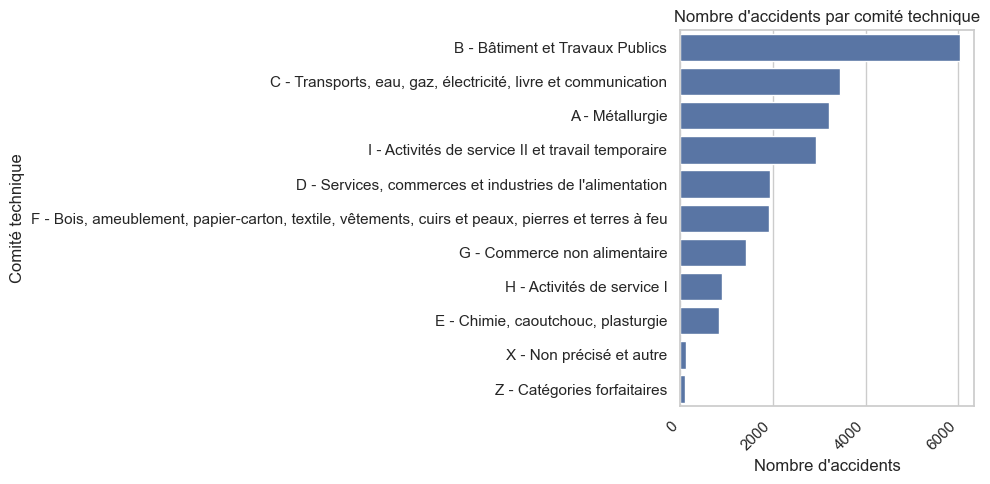

In [9]:
tc_counts = (df["technical_committee"].value_counts().reset_index())
tc_counts.columns = ["technical_committee", "nb_accidents"]

# seaborn 
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tc_counts,
    y="technical_committee",
    x="nb_accidents"
)

plt.title("Nombre d'accidents par comité technique")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Comité technique")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# Sécuriser le type texte
df["accident_summary"] = df["accident_summary"].astype(str)
# Longueur du texte
#df["summary_length_chars"] = df["accident_summary"].str.len()
# Nombre de mots
df["summary_length_words"] = df["accident_summary"].str.split().str.len()

In [11]:
text_stats = (
    df
    .groupby("technical_committee")
    .agg(
        nb_accidents=("accident_summary", "count"),
        #avg_chars=("summary_length_chars", "mean"),
        #median_chars=("summary_length_chars", "median"),
        avg_words=("summary_length_words", "mean"),
        median_words=("summary_length_words", "median")
    )
    .reset_index()
)

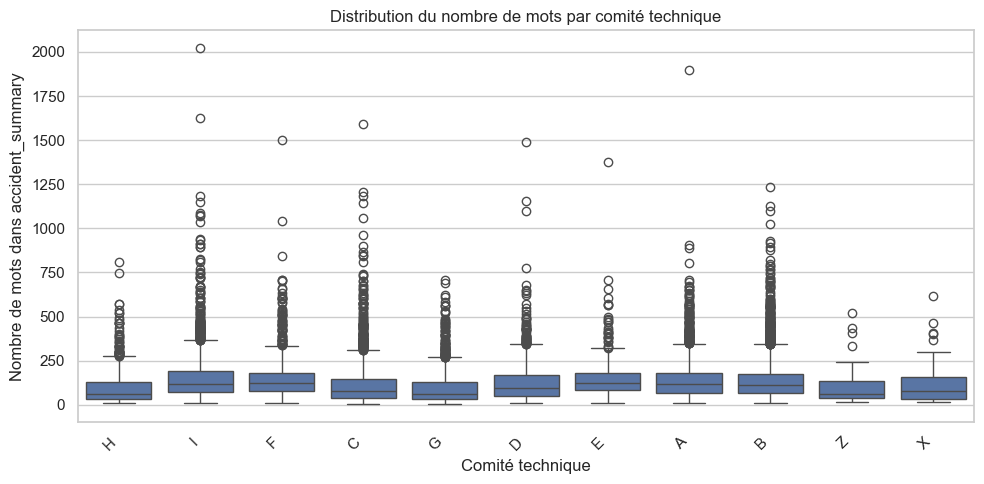

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="code",
    y="summary_length_words"
)
plt.title("Distribution du nombre de mots par comité technique")
plt.xlabel("Comité technique")
plt.ylabel("Nombre de mots dans accident_summary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Travail sur un seul domaine : B – Bâtiment et Travaux Publics (BTP)

Plus grand volume : 5 768 accidents → tu auras des résultats stables, moins sensibles au hasard.
Textes assez riches : médiane ~109 mots / 648 chars → assez d’information narrative pour extraire des patterns.
le BTP est connu pour ses scénarios accidentels récurrents → idéal pour montrer que ton approche retrouve des thèmes actionnables.

Pourquoi se restreindre à un domaine ?
- Réduit l’hétérogénéité des récits : Sur tout EPICEA, tu vas mélanger des activités, matériels, organisations, vocabulaires et styles d’enquête très différents / Résultat : tes modèles (topics, extraction de facteurs, clustering) apprennent surtout la diversité “métier” plutôt que des mécanismes actionnables.
- Rend les “facteurs génériques” plus stables : Un facteur générique utile doit être suffisamment récurrent et comparable. / Dans un domaine homogène, tu auras moins de variantes lexicales extrêmes et moins de facteurs “spécifiques à une industrie” qui parasitent.
- Facilite l’évaluation : Tu peux mieux juger si un facteur est cohérent et actionnable parce que le contexte métier est constant. / Les scénarios BN seront plus interprétables.



C:\Users\aho\AppData\Local\Temp\ipykernel_13300\1374370431.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_photo  = s.str.contains(r"photo(s)?(?=[\W_]|$)", case=False, regex=True)
C:\Users\aho\AppData\Local\Temp\ipykernel_13300\1374370431.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_schema = s.str.contains(r"sch[ée]ma(s)?(?=[\W_]|$)", case=False, regex=True)
C:\Users\aho\AppData\Local\Temp\ipykernel_13300\1374370431.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_arbre  = s.str.contains(r"arbre(s)?(?=[\W_]|$)", case=False, regex=True)


arbre des causes      395
photo                1499
schéma                355
aucun fichier       20593
Name: count, dtype: int64


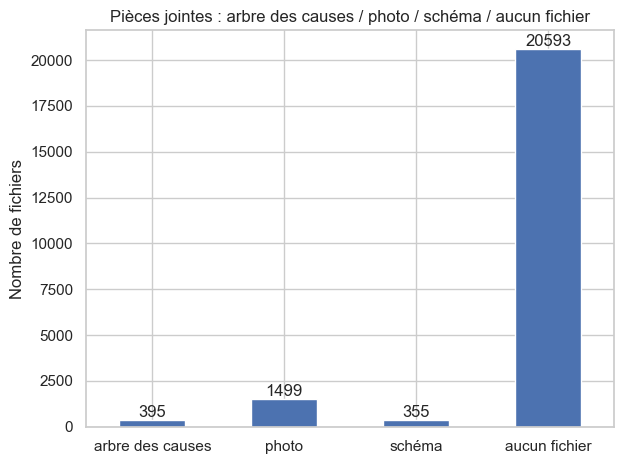

In [13]:
s = df["attachment_filename"].astype("string").fillna("").str.strip()

mask_photo  = s.str.contains(r"photo(s)?(?=[\W_]|$)", case=False, regex=True)
mask_schema = s.str.contains(r"sch[ée]ma(s)?(?=[\W_]|$)", case=False, regex=True)
mask_arbre  = s.str.contains(r"arbre(s)?(?=[\W_]|$)", case=False, regex=True)

# Catégories exclusives (priorité : arbre > photo > schéma > aucun fichier)
cat = pd.Series("aucun fichier", index=df.index)
cat[mask_schema] = "schéma"
cat[mask_photo]  = "photo"
cat[mask_arbre]  = "arbre des causes"

labels_order = ["arbre des causes", "photo", "schéma", "aucun fichier"]
counts = cat.value_counts().reindex(labels_order, fill_value=0)

print(counts)

ax = counts.plot(kind="bar", rot=0)
ax.set_title("Pièces jointes : arbre des causes / photo / schéma / aucun fichier")
ax.set_xlabel("")
ax.set_ylabel("Nombre de fichiers")

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

C:\Users\aho\AppData\Local\Temp\ipykernel_13300\86054253.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_photo  = s.str.contains(r"photo(s)?(?=[\W_]|$)", case=False, regex=True)
C:\Users\aho\AppData\Local\Temp\ipykernel_13300\86054253.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_schema = s.str.contains(r"sch[ée]ma(s)?(?=[\W_]|$)", case=False, regex=True)
C:\Users\aho\AppData\Local\Temp\ipykernel_13300\86054253.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_arbre  = s.str.contains(r"arbre(s)?(?=[\W_]|$)", case=False, regex=True)


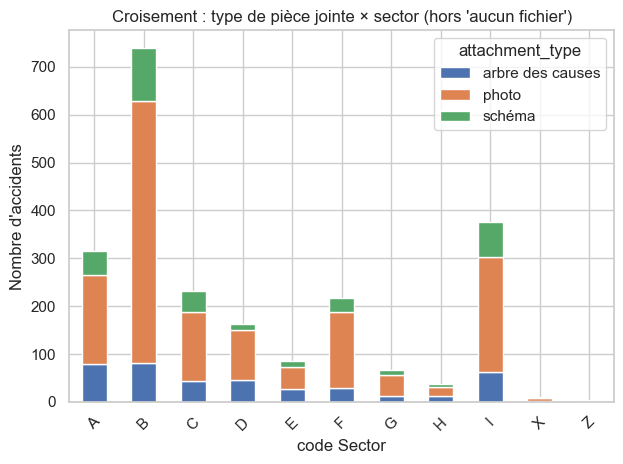

In [14]:


# --- 1) Type d'attachment (arbre/photo/schéma/aucun fichier) ---
s = df["attachment_filename"].astype("string").fillna("").str.strip()

mask_photo  = s.str.contains(r"photo(s)?(?=[\W_]|$)", case=False, regex=True)
mask_schema = s.str.contains(r"sch[ée]ma(s)?(?=[\W_]|$)", case=False, regex=True)
mask_arbre  = s.str.contains(r"arbre(s)?(?=[\W_]|$)", case=False, regex=True)

df = df.copy()
df["attachment_type"] = "aucun fichier"
df.loc[mask_schema, "attachment_type"] = "schéma"
df.loc[mask_photo,  "attachment_type"] = "photo"
df.loc[mask_arbre,  "attachment_type"] = "arbre des causes"

# --- 2) Sector (si pas déjà présent) ---
if "sector" not in df.columns:
    tc = df["code"].astype("string").str.strip()
    parts = tc.str.split(r"\s*-\s*", n=1, expand=True)
    df["sector"] = parts[1].where(tc.notna(), pd.NA)

df["sector"] = df["sector"].fillna("Non renseigné")

# --- 3) Tableau croisé SANS la classe "aucun fichier" ---
keep_types = ["arbre des causes", "photo", "schéma"]
df_plot = df[df["attachment_type"].isin(keep_types)]

ct = pd.crosstab(df_plot["code"], df_plot["attachment_type"]).reindex(columns=keep_types, fill_value=0)


# --- 4) Barplot empilé ---
ax = ct.plot(kind="bar", stacked=True, rot=45)
ax.set_title("Croisement : type de pièce jointe × sector (hors 'aucun fichier')")
ax.set_xlabel("code Sector")
ax.set_ylabel("Nombre d'accidents")
plt.tight_layout()
plt.show()


In [23]:
df["technical_committee"].value_counts()

technical_committee
B - Bâtiment et Travaux Publics                                                                      6040
C - Transports, eau, gaz, électricité, livre et communication                                        3457
A - Métallurgie                                                                                      3212
I - Activités de service II et travail temporaire                                                    2939
D - Services, commerces et industries de l'alimentation                                              1929
F - Bois, ameublement, papier-carton, textile, vêtements, cuirs et peaux, pierres et terres à feu    1920
G - Commerce non alimentaire                                                                         1412
H - Activités de service I                                                                            895
E - Chimie, caoutchouc, plasturgie                                                                    838
X - Non précisé et autre  

In [24]:
metallurgie = df.loc[df["code"]=="A"][['division','equipment_involved','company_code',"accident_id","accident_summary"]]
service_temporaire = df.loc[df["code"]=="I"][['division','equipment_involved','company_code',"accident_id","accident_summary"]]
btp = df.loc[df["code"]=="B"][['division','equipment_involved','company_code',"accident_id","accident_summary"]]
caou_chimie_plas = df.loc[df["code"]=="E"][['division','equipment_involved','company_code',"accident_id","accident_summary"]]
bois_textille  = df.loc[df["code"]=="F"][['division','equipment_involved','company_code',"accident_id","accident_summary"]]

In [26]:
metallurgie.to_excel("data/metallurgie_accident.xlsx")
btp.to_excel("data/btp_accident.xlsx")
service_temporaire.to_excel("data/service_temporaire_accident.xlsx")
caou_chimie_plas.to_excel("data/caou_chimie_plas_accident.xlsx")
bois_textille.to_excel("data/bois_textille_accident.xlsx")